# Obtención de medidas de componentes de ERP

In [1]:
from pathlib import Path

import mne
import pandas as pd

In [2]:
tmin = 0.15
tmax = 0.25
duration = tmax - tmin
channels = ['FCZ', 'CZ', 'FZ']
h_freq_amplitude = None
h_freq_latency = 10

## Carga de datos de sujetos y de procesamiento de los EEG

In [3]:
# Cargar reporte de procesamiento
PREP_DIR = Path().resolve().parent / 'preprocessing'
report = pd.read_csv(PREP_DIR / 'log_processing.csv')
report = report.set_index('Subject')
report.head()

,Bad channels,Total bad channels,Bad ICA components,Total bad ICA components,Total bad epochs
Subject,,,,,
21100,"['POZ', 'FC5', 'PZ', 'PO3']",4,"[np.int64(0), np.int64(23), np.int64(1), 2, 4,...",12,4
21101,"['AF7', 'FP2', 'PO7', 'AF8', 'PO4', 'FP1']",6,"[np.int64(2), np.int64(14), 0, 3, 4, 6, 7, 11,...",11,3
21102,"['P1', 'PO3']",2,"[np.int64(0), np.int64(29), 18, 21, 28, 38, 42...",9,0
21103,"['P1', 'P2', 'P4', 'P10']",4,"[np.int64(0), np.int64(2), 9, 26, 39, 40]",6,70
21104,"['P8', 'IZ', 'FPZ', 'FP2', 'P2', 'T8']",6,"[np.int64(1), np.int64(2), 34, 43]",4,48


In [4]:
BEHAVIORAL_DIR = Path().resolve().parent / 'data' / 'behavioral'

datos_sujetos = pd.read_csv(
    BEHAVIORAL_DIR / 'Datos_IAT_comportamentales_personales.csv'
    )

datos_sujetos = datos_sujetos.set_index('subject')
# Reemplazar "control" por "nonvictim"
datos_sujetos['type'] = datos_sujetos['type'].replace({'control':'nonvictim'})
# Reemplazar "control" por "nonvictim"
datos_sujetos['group'] = datos_sujetos['group'].replace({'control':'nonvictim'})
datos_sujetos.head()

,type,exposure_level,group,victim_self,victim_self_id,age,scholarship,gender,laterality,dscore_0,...,DAP,AAP,TPA,TPV,EASPA,ANA,BN,ANC,AGA.1,TAPV
subject,,,,,,,,,,,,,,,,,,,,,
21100,excombatant,high,exguerrilla,yes,yes,19,11,F,D,-0.197633,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21101,excombatant,high,exparamilitar,yes,yes,46,11,M,D,-0.116918,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
21102,excombatant,low,exparamilitar,yes,yes,31,11,M,D,0.473119,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21103,excombatant,high,exparamilitar,yes,yes,42,18,M,D,0.214867,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21104,excombatant,high,exparamilitar,yes,yes,38,11,M,D,0.423545,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
features_to_merge = [
    'type',
    'group',
    'victim_self',
    'exposure_level',
    'age',
    'gender',
    'scholarship',
    'laterality',
    ]

report = report.merge(
    datos_sujetos[features_to_merge], 
    left_index=True, 
    right_index=True
    )

# Delete control type and ex-both-sides group
#report = report[report['group'] != 'ex-both-sides']

report.head()

,Bad channels,Total bad channels,Bad ICA components,Total bad ICA components,Total bad epochs,type,group,victim_self,exposure_level,age,gender,scholarship,laterality
Subject,,,,,,,,,,,,,
21100,"['POZ', 'FC5', 'PZ', 'PO3']",4,"[np.int64(0), np.int64(23), np.int64(1), 2, 4,...",12,4,excombatant,exguerrilla,yes,high,19,F,11,D
21101,"['AF7', 'FP2', 'PO7', 'AF8', 'PO4', 'FP1']",6,"[np.int64(2), np.int64(14), 0, 3, 4, 6, 7, 11,...",11,3,excombatant,exparamilitar,yes,high,46,M,11,D
21102,"['P1', 'PO3']",2,"[np.int64(0), np.int64(29), 18, 21, 28, 38, 42...",9,0,excombatant,exparamilitar,yes,low,31,M,11,D
21103,"['P1', 'P2', 'P4', 'P10']",4,"[np.int64(0), np.int64(2), 9, 26, 39, 40]",6,70,excombatant,exparamilitar,yes,high,42,M,18,D
21104,"['P8', 'IZ', 'FPZ', 'FP2', 'P2', 'T8']",6,"[np.int64(1), np.int64(2), 34, 43]",4,48,excombatant,exparamilitar,yes,high,38,M,11,D


## Análisis de artefactos

In [6]:
report.groupby('type')[
	['Total bad epochs', 'Total bad channels', 'Total bad ICA components']
].agg(['mean', 'std', 'min', 'max'])

Total bad epochs                     Total bad channels            \
                        mean        std min  max               mean       std   
type                                                                            
excombatant        15.051724  22.475267   0  104           4.844828  3.088188   
nonvictim          10.625000  18.881649   0   67           3.000000  2.309401   
victim              9.347826   8.621372   0   35           6.347826  3.458963   

                    Total bad ICA components                    
            min max                     mean       std min max  
type                                                            
excombatant   0  12                 9.586207  4.530731   2  26  
nonvictim     0   8                 8.875000  3.844910   3  15  
victim        1  14                10.869565  4.929543   2  20

In [7]:
# Sujetos con muchos artefactos
bad_subjects = report[
	(report['Total bad epochs'] > 130 * 0.3)
	| (report['Total bad channels'] > 64 * 0.3)
	| (report['Total bad ICA components'] > 64 * 0.3)
]

bad_subjects

,Bad channels,Total bad channels,Bad ICA components,Total bad ICA components,Total bad epochs,type,group,victim_self,exposure_level,age,gender,scholarship,laterality
Subject,,,,,,,,,,,,,
21103,"['P1', 'P2', 'P4', 'P10']",4,"[np.int64(0), np.int64(2), 9, 26, 39, 40]",6,70,excombatant,exparamilitar,yes,high,42,M,18,D
21104,"['P8', 'IZ', 'FPZ', 'FP2', 'P2', 'T8']",6,"[np.int64(1), np.int64(2), 34, 43]",4,48,excombatant,exparamilitar,yes,high,38,M,11,D
21106,"['PZ', 'P1', 'T7']",3,"[np.int64(1), np.int64(0), np.int64(9), 4, 11,...",9,46,excombatant,exguerrilla,no,low,28,M,5,D
21129,[],0,"[np.int64(0), np.int64(7), 2, 3, 4, 5, 6, 9, 1...",17,77,excombatant,exparamilitar,yes,high,30,M,10,D
21135,"['P1', 'OZ', 'IZ', 'O1', 'P2', 'PO3', 'POZ']",7,"[np.int64(5), np.int64(0), 15, 16, 22, 30, 32,...",8,58,excombatant,exparamilitar,yes,high,50,M,14,D
21139,['IZ'],1,"[np.int64(0), 7, 9, 14, 19, 22, 23, 31, 32, 43...",11,65,excombatant,exparamilitar,no,high,38,M,9,D
22116,['P7'],1,"[np.int64(8), np.int64(9), 33]",3,67,nonvictim,nonvictim,no,low,27,M,11,D
23002,"['P1', 'AF7', 'PO3', 'P9', 'POZ', 'T8']",6,"[np.int64(3), np.int64(1), np.int64(0), np.int...",26,0,excombatant,exparamilitar,no,low,48,M,6,D
23012,"['C3', 'P6', 'P2', 'PO3', 'PO7', 'TP7']",6,"[np.int64(0), 29, 35, 37]",4,104,excombatant,exguerrilla,yes,high,43,M,5,D


In [8]:
bad_subjects['type'].value_counts()

type
excombatant    8
nonvictim      1
victim         1
Name: count, dtype: int64

In [9]:
preserved = report[~report.index.isin(bad_subjects.index)]
preserved.index = preserved.index.astype(str)
preserved.head()

,Bad channels,Total bad channels,Bad ICA components,Total bad ICA components,Total bad epochs,type,group,victim_self,exposure_level,age,gender,scholarship,laterality
Subject,,,,,,,,,,,,,
21100,"['POZ', 'FC5', 'PZ', 'PO3']",4,"[np.int64(0), np.int64(23), np.int64(1), 2, 4,...",12,4,excombatant,exguerrilla,yes,high,19,F,11,D
21101,"['AF7', 'FP2', 'PO7', 'AF8', 'PO4', 'FP1']",6,"[np.int64(2), np.int64(14), 0, 3, 4, 6, 7, 11,...",11,3,excombatant,exparamilitar,yes,high,46,M,11,D
21102,"['P1', 'PO3']",2,"[np.int64(0), np.int64(29), 18, 21, 28, 38, 42...",9,0,excombatant,exparamilitar,yes,low,31,M,11,D
21105,"['P1', 'IZ', 'P3', 'O1', 'P2', 'PO3', 'PO7', '...",10,"[np.int64(0), np.int64(3), 4, 9, 12, 23, 25, 2...",9,4,excombatant,exparamilitar,yes,high,48,M,8,D
21107,"['P1', 'T7', 'IZ', 'PO7', 'PZ']",5,"[np.int64(0), np.int64(1), np.int64(4), 3, 6, ...",14,9,excombatant,exguerrilla,no,high,25,M,11,D


In [10]:
preserved['type'].value_counts()

type
excombatant    50
victim         22
nonvictim      15
Name: count, dtype: int64

## Gráficas

In [11]:
EEG_DIR = Path().resolve().parent / 'data' / 'eeg-processed'
eeg_paths = sorted(EEG_DIR.glob('*.fif'))

In [12]:
def load_epochs(eeg_paths=eeg_paths, h_freq=h_freq_amplitude):
    evocados_co = {}
    evocados_in = {}

    for ruta in eeg_paths:
        epochs = mne.read_epochs(ruta)
        subject_id = ruta.stem.split('_')[0]
        evoked_co = epochs['12', '13', '14', '15', '16', '17', '18', '19'].average()
        evoked_co = evoked_co.filter(l_freq=None, h_freq=h_freq)
        evocados_co[subject_id] = evoked_co
        evoked_in = epochs['24', '25', '26', '27', '28', '29', '30', '31'].average()
        evoked_in = evoked_in.filter(l_freq=None, h_freq=h_freq)
        evocados_in[subject_id] = evoked_in
    return evocados_co, evocados_in

In [13]:
evocados_co, evocados_in = load_epochs()

Reading C:\Users\Usuario\repos\iat-eeg\data\eeg-processed\21100_epo.fif ...
    Found the data of interest:
        t =    -199.22 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
145 matching events found
No baseline correction applied
0 projection items activated

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal allpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Filter length: 1 samples (0.004 s)


FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal allpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Filter length: 1 samples (0.004 s)

Reading C:\Users\Usuario\repos\iat-eeg\data\eeg-processed\21101_epo.fif ...
    Found the data of interest:
        t =    -199.22 ...    2000.00 ms
        0 CTF com

In [14]:
victimas = preserved[preserved['type'] == 'victim'].index
no_victimas = preserved[preserved['type'] == 'nonvictim'].index

victimas_co = [evocados_co[sujeto] for sujeto in victimas]
victimas_in = [evocados_in[sujeto] for sujeto in victimas]
no_victimas_co = [evocados_co[sujeto] for sujeto in no_victimas]
no_victimas_in = [evocados_in[sujeto] for sujeto in no_victimas]

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


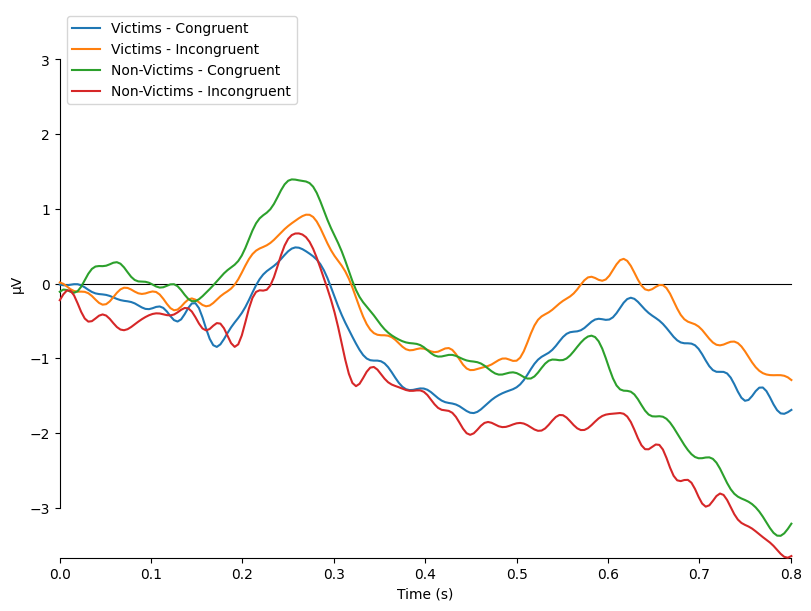

[<Figure size 800x600 with 1 Axes>]

In [17]:
# Visualización de los ERPs en los canales seleccionados

tmin_fig = 0.0
tmax_fig = 0.8

victimas_co_cluster = [
    erp.copy().crop(tmin=tmin_fig, tmax=tmax_fig).pick(channels) for erp in victimas_co
    ]
victimas_in_cluster = [
    erp.copy().crop(tmin=tmin_fig, tmax=tmax_fig).pick(channels) for erp in victimas_in
    ]
no_victimas_co_cluster = [
    erp.copy().crop(tmin=tmin_fig, tmax=tmax_fig).pick(channels) for erp in no_victimas_co  # noqa: E501
    ]
no_victimas_in_cluster = [
    erp.copy().crop(tmin=tmin_fig, tmax=tmax_fig).pick(channels) for erp in no_victimas_in  # noqa: E501
    ]

evokeds = {
    'Victims - Congruent': victimas_co_cluster,
    'Victims - Incongruent': victimas_in_cluster,
    'Non-Victims - Congruent': no_victimas_co_cluster,
    'Non-Victims - Incongruent': no_victimas_in_cluster
}

mne.viz.plot_compare_evokeds(
    evokeds=evokeds,
    combine='mean',
    ci=False,
    split_legend=True
)

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


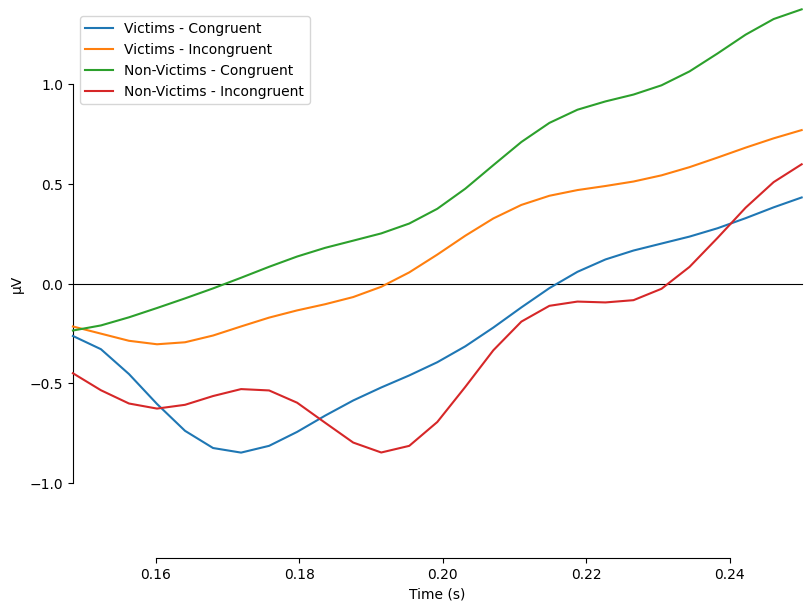

[<Figure size 800x600 with 1 Axes>]

In [18]:
# Visualización de los ERPs en los canales seleccionados en la ventana de interés

tmin_fig = tmin
tmax_fig = tmax

victimas_co_cluster = [
    erp.copy().crop(tmin=tmin_fig, tmax=tmax_fig).pick(channels) for erp in victimas_co
    ]
victimas_in_cluster = [
    erp.copy().crop(tmin=tmin_fig, tmax=tmax_fig).pick(channels) for erp in victimas_in
    ]
no_victimas_co_cluster = [
    erp.copy().crop(tmin=tmin_fig, tmax=tmax_fig).pick(channels) for erp in no_victimas_co  # noqa: E501
    ]
no_victimas_in_cluster = [
    erp.copy().crop(tmin=tmin_fig, tmax=tmax_fig).pick(channels) for erp in no_victimas_in  # noqa: E501
    ]

evokeds = {
    'Victims - Congruent': victimas_co_cluster,
    'Victims - Incongruent': victimas_in_cluster,
    'Non-Victims - Congruent': no_victimas_co_cluster,
    'Non-Victims - Incongruent': no_victimas_in_cluster
}

mne.viz.plot_compare_evokeds(
    evokeds=evokeds,
    combine='mean',
    ci=False,
    split_legend=True
)

In [19]:
victimas_co_grand_average = mne.grand_average(victimas_co)
victimas_in_grand_average = mne.grand_average(victimas_in)
no_victimas_co_grand_average = mne.grand_average(no_victimas_co)
no_victimas_in_grand_average = mne.grand_average(no_victimas_in)

Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...


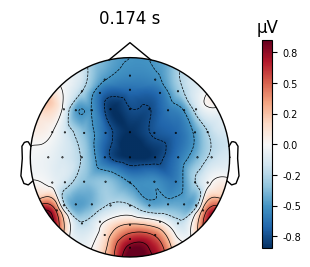

In [ ]:
victimas_co_grand_average.plot_topomap(
    times=[0.175],
    res=300,
    size=2
    );

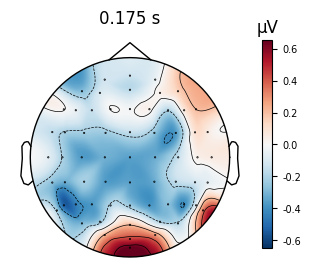

In [22]:
victimas_in_grand_average.plot_topomap(
    times=[0.175],
    res=300,
    size=2
    );

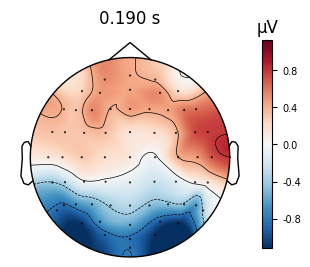

In [23]:
no_victimas_co_grand_average.plot_topomap(
    times=[0.190],
    res=300,
    size=2
    );

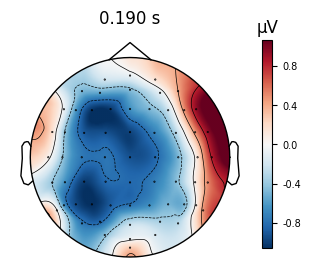

In [24]:
no_victimas_in_grand_average.plot_topomap(
    times=[0.190],
    res=300,
    size=2
    );

## Medidas

In [25]:
# Función que calcula el erp grand-average de una ROI dada una lista de canales
def ROI_evoked(evocado, canales):
    lista_canales = evocado.ch_names
    lista_indices = []
    for canal in canales:
        indice = lista_canales.index(canal)
        lista_indices.append(indice)
    ROI_evocado = mne.channels.combine_channels(evocado, groups={'ROI':lista_indices})
    return ROI_evocado

# Función que entrega diccionarios de erp de ROIs por tipo de ensayo
def rois(canales, df_sujetos, evocados_co, evocados_in, t_min=.0, t_max=.8):
    ROI_co = {}
    ROI_in = {}
    ROI_dif = {}
    
    for sujeto in df_sujetos.index:
        ROI_co[sujeto] = ROI_evoked(evocados_co[sujeto],canales).crop(
            tmin=t_min,
            tmax=t_max
            )
        ROI_in[sujeto] = ROI_evoked(evocados_in[sujeto],canales).crop(
            tmin=t_min,
            tmax=t_max
            )
        data_dif = ROI_co[sujeto].data - ROI_in[sujeto].data
        ROI_dif[sujeto] = mne.EvokedArray(
            data=data_dif, 
            info=ROI_in[sujeto].info, 
            tmin=ROI_in[sujeto].tmin
            )

    return ROI_co, ROI_in, ROI_dif

In [27]:
# Cálculo de media de un erp de un ROI
def mean_peak_amplitude(
        tmin=tmin, 
        tmax=tmax, 
        channels=channels, 
        eeg_paths=eeg_paths, 
        preserved=preserved, 
        h_freq=h_freq_amplitude
        ):
    
    evocados_co, evocados_in = load_epochs(eeg_paths, h_freq=h_freq)
    
    ROI_co, ROI_in, ROI_dif = rois(
    canales=channels,
    df_sujetos=preserved,
    evocados_co=evocados_co, 
    evocados_in=evocados_in,
    )
    mean_amplitude_co = {}
    mean_amplitude_in = {}
    mean_amplitude_dif = {}
    peak_amplitude_co = {}
    peak_amplitude_in = {}
    peak_amplitude_dif = {}

    for sujeto in preserved.index:
        erp_co = ROI_co[sujeto].crop(tmin = tmin, tmax = tmax)
        data_co = erp_co.to_data_frame(time_format = None)
        data_co.set_index('time',inplace=True)
        mean_amplitude_co[sujeto] = data_co.mean()
        peak_amplitude_co[sujeto] = data_co.min()
        
        erp_in = ROI_in[sujeto].crop(tmin = tmin, tmax = tmax)
        data_in = erp_in.to_data_frame(time_format = None)
        data_in.set_index('time',inplace=True)
        mean_amplitude_in[sujeto] = data_in.mean()
        peak_amplitude_in[sujeto] = data_in.min()

        erp_dif = ROI_dif[sujeto].crop(tmin = tmin, tmax = tmax)
        data_dif = erp_dif.to_data_frame(time_format = None)
        data_dif.set_index('time',inplace=True)
        mean_amplitude_dif[sujeto] = data_dif.mean()
        peak_amplitude_dif[sujeto] = data_dif.min()

    mean_amplitude_co_df = pd.DataFrame.from_dict(mean_amplitude_co, orient='index')
    mean_amplitude_co_df.rename(columns={'ROI': 'mean_amplitude_co'}, inplace=True)
    mean_amplitude_in_df = pd.DataFrame.from_dict(mean_amplitude_in, orient='index')
    mean_amplitude_in_df.rename(columns={'ROI': 'mean_amplitude_in'}, inplace=True)
    mean_amplitude_dif_df = pd.DataFrame.from_dict(mean_amplitude_dif, orient='index')
    mean_amplitude_dif_df.rename(columns={'ROI': 'mean_amplitude_dif'}, inplace=True)
    peak_amplitude_co_df = pd.DataFrame.from_dict(peak_amplitude_co, orient='index')
    peak_amplitude_co_df.rename(columns={'ROI': 'peak_amplitude_co'}, inplace=True)
    peak_amplitude_in_df = pd.DataFrame.from_dict(peak_amplitude_in, orient='index')
    peak_amplitude_in_df.rename(columns={'ROI': 'peak_amplitude_in'}, inplace=True)
    peak_amplitude_dif_df = pd.DataFrame.from_dict(peak_amplitude_dif, orient='index')
    peak_amplitude_dif_df.rename(columns={'ROI': 'peak_amplitude_dif'}, inplace=True)
    mean_peak_amplitude_df = pd.concat([
        mean_amplitude_co_df, 
        mean_amplitude_in_df, 
        mean_amplitude_dif_df,
        peak_amplitude_co_df,
        peak_amplitude_in_df,
        peak_amplitude_dif_df
        ], axis=1)
    
    return mean_peak_amplitude_df

In [28]:
mean_peak_amplitude_df = mean_peak_amplitude()
mean_peak_amplitude_df

Reading C:\Users\Usuario\repos\iat-eeg\data\eeg-processed\21100_epo.fif ...
    Found the data of interest:
        t =    -199.22 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
145 matching events found
No baseline correction applied
0 projection items activated

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal allpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Filter length: 1 samples (0.004 s)


FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal allpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Filter length: 1 samples (0.004 s)

Reading C:\Users\Usuario\repos\iat-eeg\data\eeg-processed\21101_epo.fif ...
    Found the data of interest:
        t =    -199.22 ...    2000.00 ms
        0 CTF com

,mean_amplitude_co,mean_amplitude_in,mean_amplitude_dif,peak_amplitude_co,peak_amplitude_in,peak_amplitude_dif
21100,0.586812,0.537628,0.049184,-0.102898,0.217525,-1.114495
21101,0.463325,1.170137,-0.706813,0.168540,0.453635,-1.258774
21102,-4.757545,-3.940181,-0.817364,-6.066593,-5.288409,-2.164558
21105,0.410431,0.404159,0.006272,-0.301943,-0.690351,-0.827955
21107,0.256688,0.392556,-0.135867,0.012856,0.149298,-0.477868
...,...,...,...,...,...,...
24059,-0.263426,-0.676478,0.413052,-0.576014,-1.386664,-0.230256
24065,-1.780049,-1.561594,-0.218455,-2.491021,-3.110198,-1.704373
24069,-0.160387,0.708211,-0.868599,-0.640499,-0.903927,-1.739222
24073,1.497754,0.364142,1.133611,-0.034800,-0.893151,0.221685


In [30]:
# Cálculo de media de un erp de un ROI
def peak_latency(
        tmin=tmin, 
        tmax=tmax, 
        channels=channels, 
        eeg_paths=eeg_paths, 
        preserved=preserved, 
        h_freq=h_freq_latency
        ):
    
    evocados_co, evocados_in = load_epochs(eeg_paths, h_freq=h_freq)
    
    ROI_co, ROI_in, __ = rois(
    canales=channels,
    df_sujetos=preserved,
    evocados_co=evocados_co, 
    evocados_in=evocados_in,
    )
    
    peak_latency_co = {}
    peak_latency_in = {}

    for sujeto in preserved.index:
        erp_co = ROI_co[sujeto].crop(tmin = tmin, tmax = tmax)
        data_co = erp_co.to_data_frame(time_format = None)
        data_co.set_index('time',inplace=True)
        peak_latency_co[sujeto] = data_co.idxmin()
        
        erp_in = ROI_in[sujeto].crop(tmin = tmin, tmax = tmax)
        data_in = erp_in.to_data_frame(time_format = None)
        data_in.set_index('time',inplace=True)
        peak_latency_in[sujeto] = data_in.idxmin()

    peak_latency_co_df = pd.DataFrame.from_dict(peak_latency_co, orient='index')
    peak_latency_co_df.rename(columns={'ROI': 'peak_latency_co'}, inplace=True)
    peak_latency_in_df = pd.DataFrame.from_dict(peak_latency_in, orient='index')
    peak_latency_in_df.rename(columns={'ROI': 'peak_latency_in'}, inplace=True)
    peak_latency_df = pd.concat([peak_latency_co_df,
                                peak_latency_in_df
                                ], axis=1)
    return peak_latency_df

In [31]:
peak_latency_df = peak_latency()
peak_latency_df

Reading C:\Users\Usuario\repos\iat-eeg\data\eeg-processed\21100_epo.fif ...
    Found the data of interest:
        t =    -199.22 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
145 matching events found
No baseline correction applied
0 projection items activated
Setting up low-pass filter at 10 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 11.25 Hz)
- Filter length: 339 samples (1.324 s)

Setting up low-pass filter at 10 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 10

,peak_latency_co,peak_latency_in
21100,0.160156,0.250000
21101,0.210938,0.148438
21102,0.199219,0.207031
21105,0.148438,0.167969
21107,0.230469,0.148438
...,...,...
24059,0.152344,0.160156
24065,0.214844,0.160156
24069,0.148438,0.148438
24073,0.148438,0.148438


# Fusión de las medidas con las características de los sujetos

In [32]:
data_subjects = datos_sujetos[[
    'type', 
    'group', 
    'victim_self', 
    'exposure_level', 
    'age', 
    'gender', 
    'scholarship', 
    'laterality', 
    'dscore_4',
    ]]
    
data_subjects = data_subjects.rename(columns={'dscore_4':'IAT_score'})
data_subjects.index = data_subjects.index.astype(str)

data_subjects = data_subjects.merge(
    pd.concat([
        mean_peak_amplitude_df, 
        peak_latency_df
        ], axis=1
        ),
    left_index=True, 
    right_index=True, 
    how='inner'
    )

data_subjects.head()

,type,group,victim_self,exposure_level,age,gender,scholarship,laterality,IAT_score,mean_amplitude_co,mean_amplitude_in,mean_amplitude_dif,peak_amplitude_co,peak_amplitude_in,peak_amplitude_dif,peak_latency_co,peak_latency_in
21100,excombatant,exguerrilla,yes,high,19,F,11,D,0.319044,0.586812,0.537628,0.049184,-0.102898,0.217525,-1.114495,0.160156,0.250000
21101,excombatant,exparamilitar,yes,high,46,M,11,D,-0.070836,0.463325,1.170137,-0.706813,0.168540,0.453635,-1.258774,0.210938,0.148438
21102,excombatant,exparamilitar,yes,low,31,M,11,D,0.488057,-4.757545,-3.940181,-0.817364,-6.066593,-5.288409,-2.164558,0.199219,0.207031
21105,excombatant,exparamilitar,yes,high,48,M,8,D,0.258352,0.410431,0.404159,0.006272,-0.301943,-0.690351,-0.827955,0.148438,0.167969
21107,excombatant,exguerrilla,no,high,25,M,11,D,-0.119566,0.256688,0.392556,-0.135867,0.012856,0.149298,-0.477868,0.230469,0.148438


array([<Axes: title={'center': 'mean_amplitude_co'}, xlabel='type'>,
       <Axes: title={'center': 'mean_amplitude_in'}, xlabel='type'>],
      dtype=object)

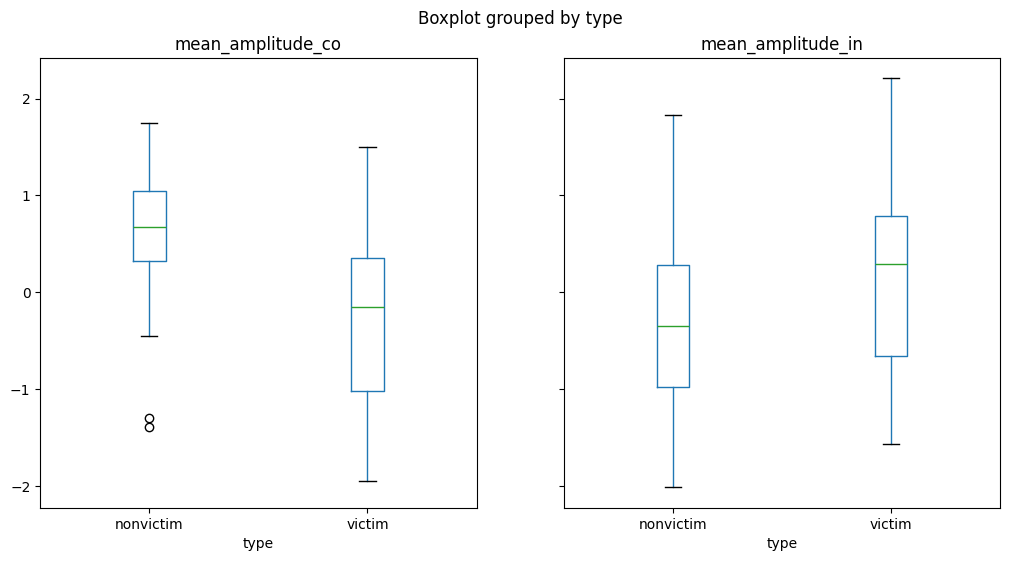

In [33]:
data_subjects[data_subjects['type'] != 'excombatant'].boxplot(
    by='type', 
    column=[
        'mean_amplitude_co', 
        'mean_amplitude_in', 
        ],
    figsize=(12, 6),
    layout=(1, 2),
    grid=False,
    sharey=True,
    sharex=False,
    )

array([<Axes: title={'center': 'peak_amplitude_co'}, xlabel='type'>,
       <Axes: title={'center': 'peak_amplitude_in'}, xlabel='type'>],
      dtype=object)

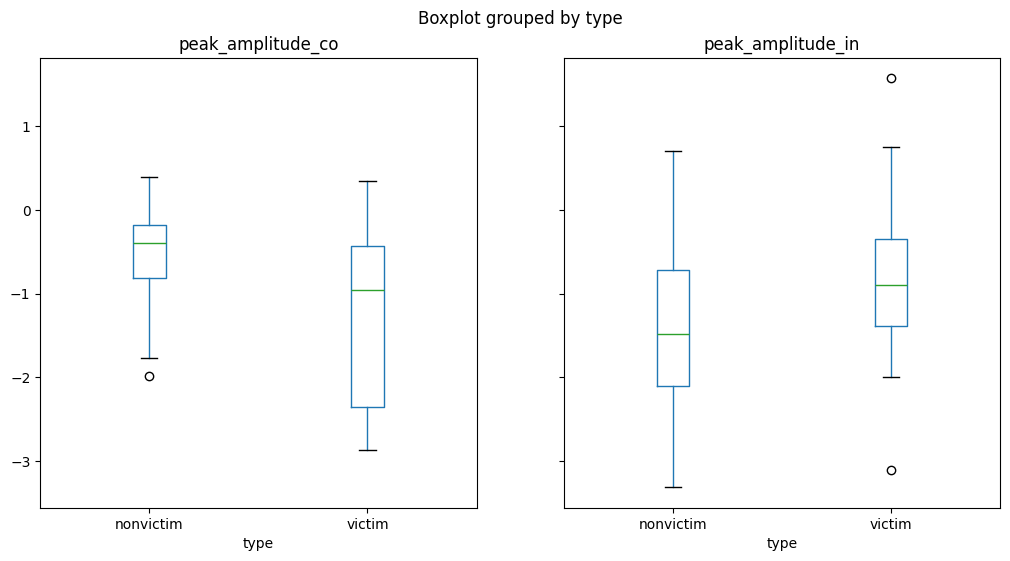

In [34]:
data_subjects[data_subjects['type'] != 'excombatant'].boxplot(
    by='type', 
    column=[
        'peak_amplitude_co', 
        'peak_amplitude_in', 
        ],
    figsize=(12, 6),
    layout=(1, 2),
    grid=False,
    sharey=True,
    sharex=False,
    )

array([<Axes: title={'center': 'peak_latency_co'}, xlabel='type'>,
       <Axes: title={'center': 'peak_latency_in'}, xlabel='type'>],
      dtype=object)

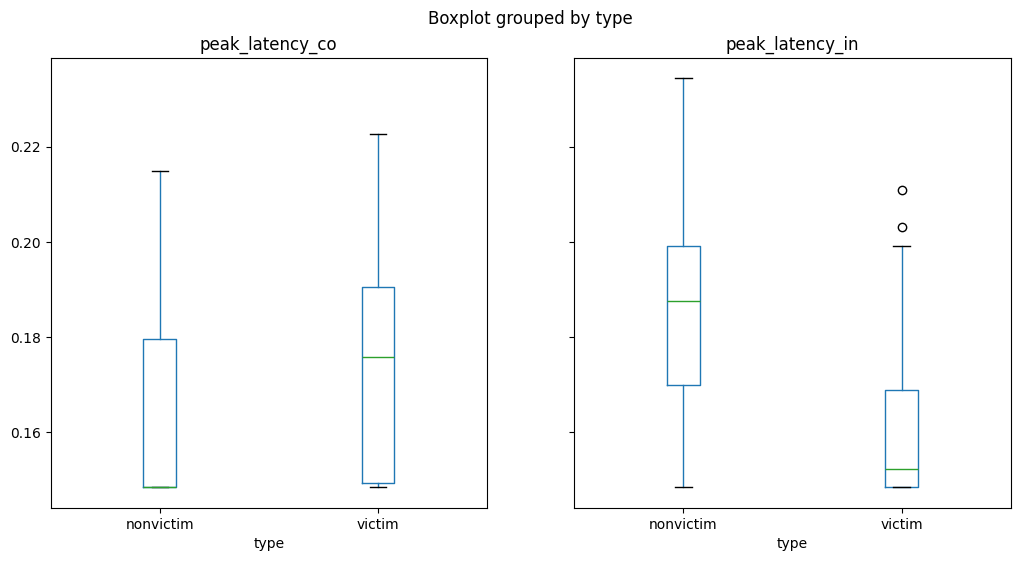

In [35]:
data_subjects[data_subjects['type'] != 'excombatant'].boxplot(
    by='type', 
    column=[
        'peak_latency_co',
        'peak_latency_in',
        ],
    figsize=(12, 6),
    layout=(1, 2),
    grid=False,
    sharey=True,
    sharex=False,
    )

In [37]:
data_subjects= data_subjects.reset_index()
data_subjects.rename(columns={'index':'subject'}, inplace=True)
data_subjects.to_csv('data_subjects.csv', index=False)